# Trabalho Prático 2: Aprendizado de Máquina (QSAR Biodegradation)
**Objetivo:** Prever a biodegradabilidade de substâncias químicas (RB vs NRB).

**Pipeline de Pré-processamento:**
1. Divisão Estratificada Imediata (80/20) para evitar *Data Leakage*.
2. Seleção de Features (Top 20) com Random Forest.
3. Tratamento Multivariado de Outliers com Isolation Forest (apenas no Treino).
4. Normalização Estatística (Z-Score).
5. Balanceamento de Classes com SMOTE aplicado **por fold** dentro do pipeline do GridSearchCV.

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento, Divisão e Validação
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# ATENÇÃO: Importamos o Pipeline do imblearn (não do sklearn) para suportar o SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Modelos Supervisionados
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Métricas de Avaliação
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento, Limpeza Básica e Divisão Imediata
Para garantir a integridade do protocolo experimental, dividimos os dados em **Treino (80%)** e **Teste (20%)** antes de aplicar qualquer técnica de redução ou tratamento. A validação é conduzida via **5-Fold Cross Validation** durante a busca de hiperparâmetros, com o SMOTE aplicado internamente em cada dobra para evitar contaminação do fold de validação.

In [2]:
# Carregamento e remoção de duplicatas/nulos
df_raw = pd.read_csv('biodeg_normalizado.csv').drop_duplicates().dropna()

target_col = 'experimental class'
X_raw = df_raw.drop(columns=[target_col])
y_raw = df_raw[target_col]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
print(f"Mapeamento do Target: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Divisão 80% Treino e 20% Teste (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_encoded, test_size=0.20, stratify=y_encoded, random_state=42
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

# Seleção de Features: Top 20 por importância RF (fit apenas no treino)
rf_selector = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_selector.fit(X_train, y_train)
importancias = pd.DataFrame({'Feature': X_train.columns, 'Imp': rf_selector.feature_importances_})
top_20 = importancias.sort_values(by='Imp', ascending=False).head(20)['Feature'].tolist()
X_train_20 = X_train[top_20]
X_test_20  = X_test[top_20]
print(f"Features reduzidas para Top 20 com sucesso.")


Mapeamento do Target: {'NRB': np.int64(0), 'RB': np.int64(1)}
Treino: 841 amostras | Teste: 211 amostras


Features reduzidas para Top 20 com sucesso.


---
## 0. Análise Exploratória dos Dados (EDA)
Antes de qualquer pré-processamento, investigamos a estrutura do dataset para embasar nossas decisões: distribuição do alvo, correlações entre features e distribuição das variáveis mais relevantes.

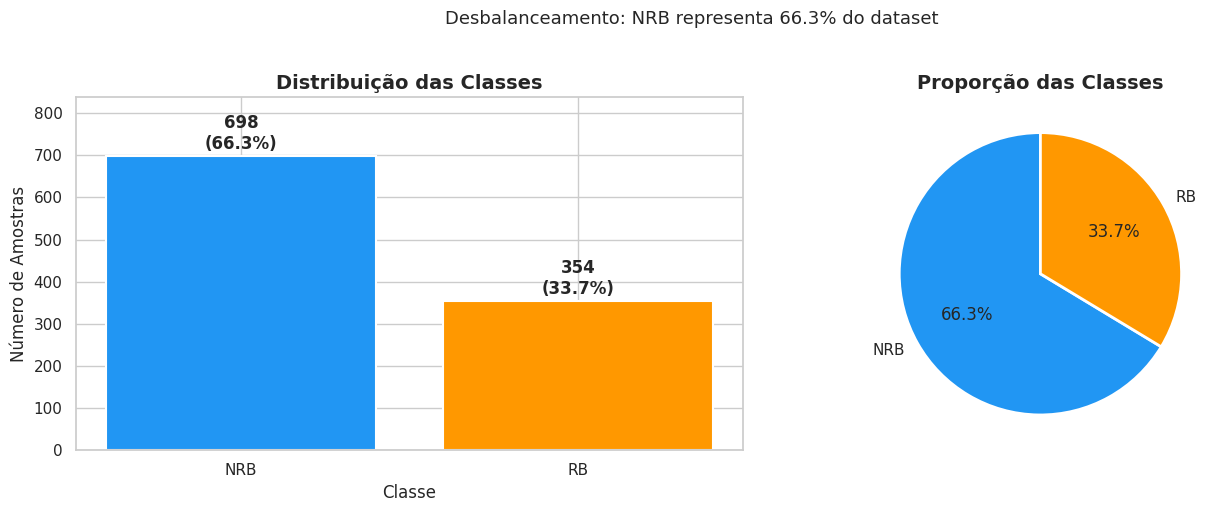

Razão NRB/RB: 1.97x — desbalanceamento moderado, justificando o uso de SMOTE.


In [3]:
# ── EDA: Distribuição das Classes ────────────────────────────────────────────
contagem = df_raw['experimental class'].value_counts()
percentuais = df_raw['experimental class'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
bars = axes[0].bar(contagem.index, contagem.values,
                   color=['#2196F3', '#FF9800'], edgecolor='white', linewidth=1.5)
for bar, val, pct in zip(bars, contagem.values, percentuais.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8, f'{val}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Distribuição das Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Número de Amostras')
axes[0].set_ylim(0, max(contagem.values) * 1.2)

# Pizza
axes[1].pie(contagem.values, labels=contagem.index,
            autopct='%1.1f%%', colors=['#2196F3', '#FF9800'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontsize=14, fontweight='bold')

plt.suptitle('Desbalanceamento: NRB representa 66.3% do dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Razão NRB/RB: {contagem['NRB']/contagem['RB']:.2f}x — desbalanceamento moderado, justificando o uso de SMOTE.")

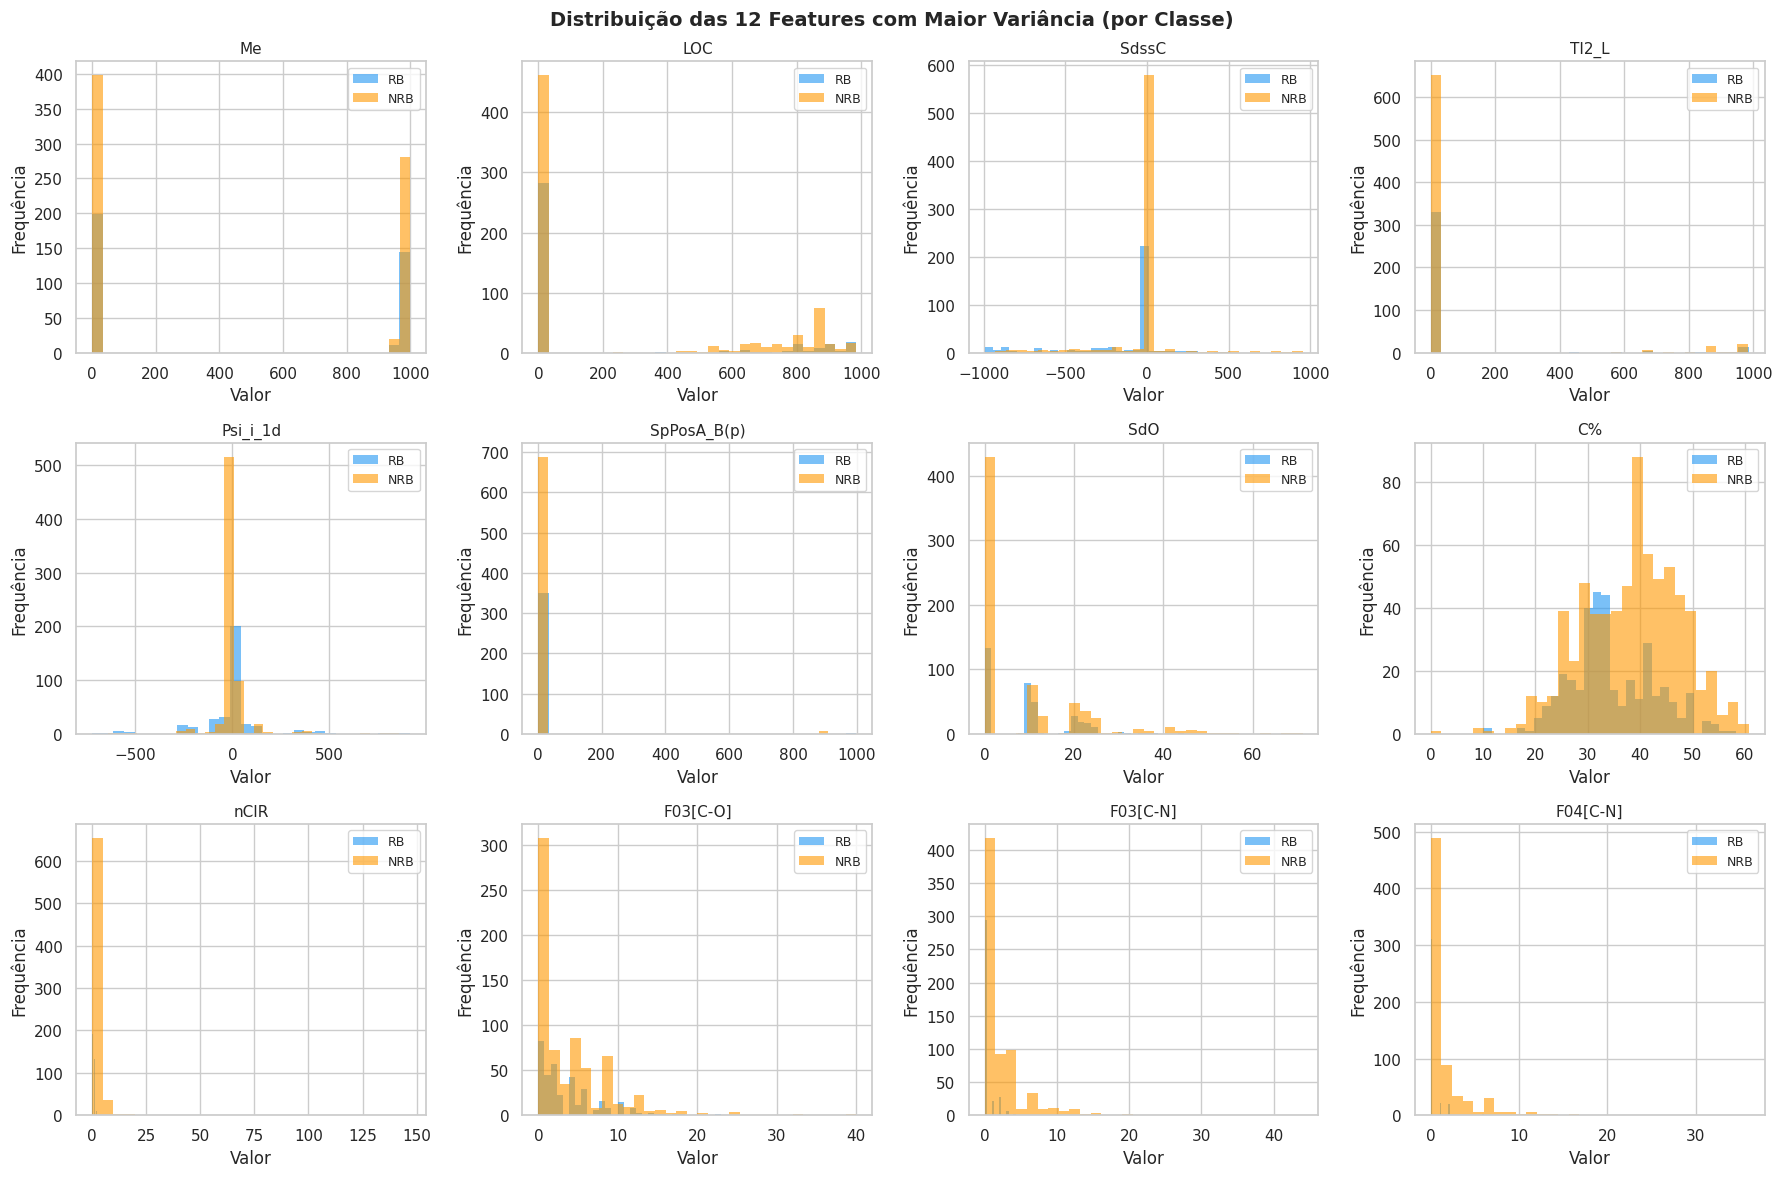

In [4]:
# ── EDA: Distribuição das Features (Top 12 por variância) ───────────────────
X_eda = df_raw.drop(columns=['experimental class'])
y_eda = df_raw['experimental class']

top12_var = X_eda.var().nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(top12_var):
    for classe, cor in zip(['RB', 'NRB'], ['#2196F3', '#FF9800']):
        axes[i].hist(df_raw[df_raw['experimental class'] == classe][feat],
                     bins=30, alpha=0.6, label=classe, color=cor, edgecolor='none')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição das 12 Features com Maior Variância (por Classe)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

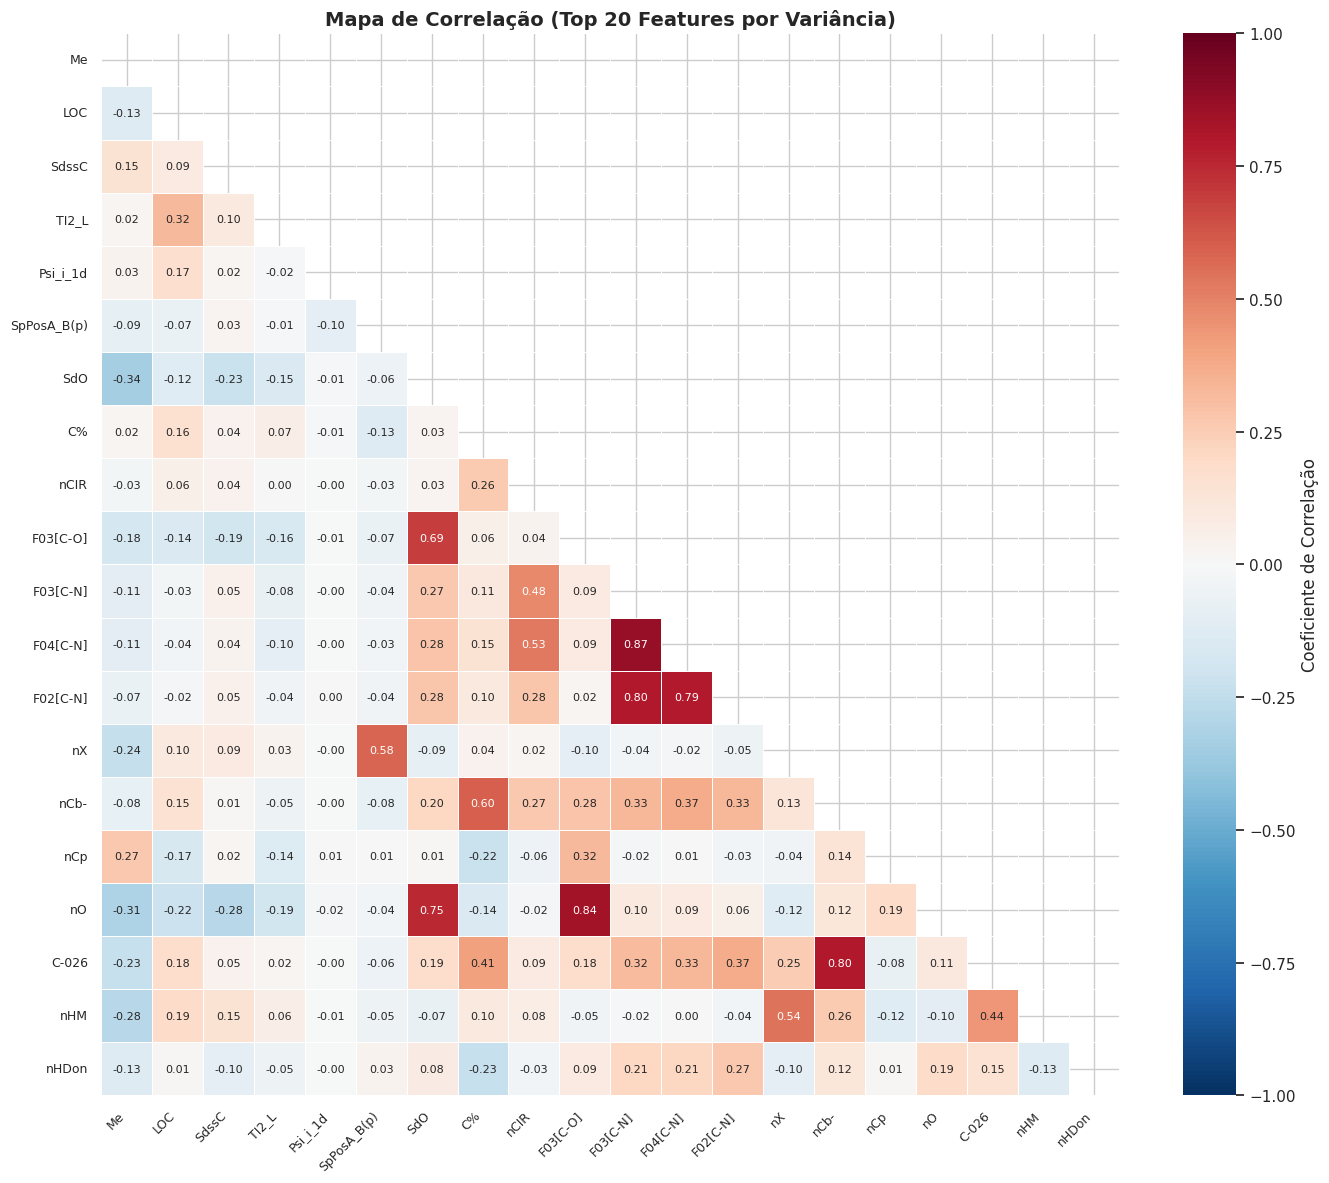

Pares com correlação |r| > 0.8 (possível redundância):
  F03[C-N] × F04[C-N]: 0.870
  F03[C-O] × nO: 0.841
  F02[C-N] × F03[C-N]: 0.804
  C-026 × nCb-: 0.800


In [5]:
# ── EDA: Mapa de Correlação ──────────────────────────────────────────────────
# Usamos as 20 features de maior variância para legibilidade
top20_var = X_eda.var().nlargest(20).index.tolist()
corr_matrix = X_eda[top20_var].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'label': 'Coeficiente de Correlação'})
plt.title('Mapa de Correlação (Top 20 Features por Variância)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Pares com correlação alta
corr_abs = corr_matrix.abs()
corr_abs_arr = corr_abs.to_numpy().copy()
np.fill_diagonal(corr_abs_arr, 0)
corr_abs = pd.DataFrame(corr_abs_arr, index=corr_abs.index, columns=corr_abs.columns)
high_corr = [(r, c, corr_matrix.loc[r, c])
             for r in corr_abs.index for c in corr_abs.columns
             if corr_abs.loc[r, c] > 0.8 and r < c]
if high_corr:
    print("Pares com correlação |r| > 0.8 (possível redundância):")
    for r, c, val in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {r} × {c}: {val:.3f}")
else:
    print("Nenhum par com correlação |r| > 0.8 encontrado nas top 20 features.")

In [6]:
# ── EDA: Estatísticas Descritivas Resumidas ──────────────────────────────────
print("=== Estatísticas Descritivas do Dataset ===")
print(f"Total de amostras: {len(df_raw)}")
print(f"Total de features: {X_eda.shape[1]}")
print(f"Valores nulos: {df_raw.isnull().sum().sum()}")
print(f"Duplicatas: {df_raw.duplicated().sum()}")
print()
display(X_eda.describe().round(3))

=== Estatísticas Descritivas do Dataset ===
Total de amostras: 1052
Total de features: 41
Valores nulos: 0
Duplicatas: 0



,SpMax_L,J_Dz(e),nHM,F01[N-N],F04[C-N],NssssC,nCb-,C%,nCp,nO,...,nCrt,C-026,F02[C-N],nHDon,SpMax_B(m),Psi_i_A,nN,SM6_B(m),nArCOOR,nX
count,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,...,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000,1052.000
mean,4.782,3.078,0.713,0.043,0.983,0.288,1.651,37.065,1.378,1.798,...,0.125,0.886,1.279,0.956,3.919,2.556,0.688,8.630,0.051,0.720
std,0.546,0.842,1.455,0.256,2.336,1.072,2.226,9.144,1.965,1.772,...,0.619,1.522,2.276,1.248,1.001,0.641,1.091,1.243,0.319,2.236
min,2.000,1.135,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,2.267,1.467,0.000,4.917,0.000,0.000
25%,4.481,2.510,0.000,0.000,0.000,0.000,0.000,30.475,0.000,0.000,...,0.000,0.000,0.000,0.000,3.488,2.102,0.000,7.992,0.000,0.000
50%,4.828,3.057,0.000,0.000,0.000,0.000,1.000,37.500,1.000,2.000,...,0.000,0.000,0.000,1.000,3.727,2.458,0.000,8.500,0.000,0.000
75%,5.125,3.437,1.000,0.000,1.000,0.000,3.000,43.350,2.000,3.000,...,0.000,1.000,2.000,2.000,3.987,2.868,1.000,9.019,0.000,0.000
max,6.496,9.178,12.000,3.000,36.000,13.000,18.000,60.700,24.000,12.000,...,8.000,12.000,18.000,7.000,10.695,5.825,8.000,14.700,4.000,27.000


## 2. Seleção de Features (Redução de Dimensionalidade)
Utilizamos uma Random Forest apenas nos dados de treino para identificar as 20 características moleculares mais importantes, aplicando o Princípio da Parcimônia e reduzindo o ruído do dataset.

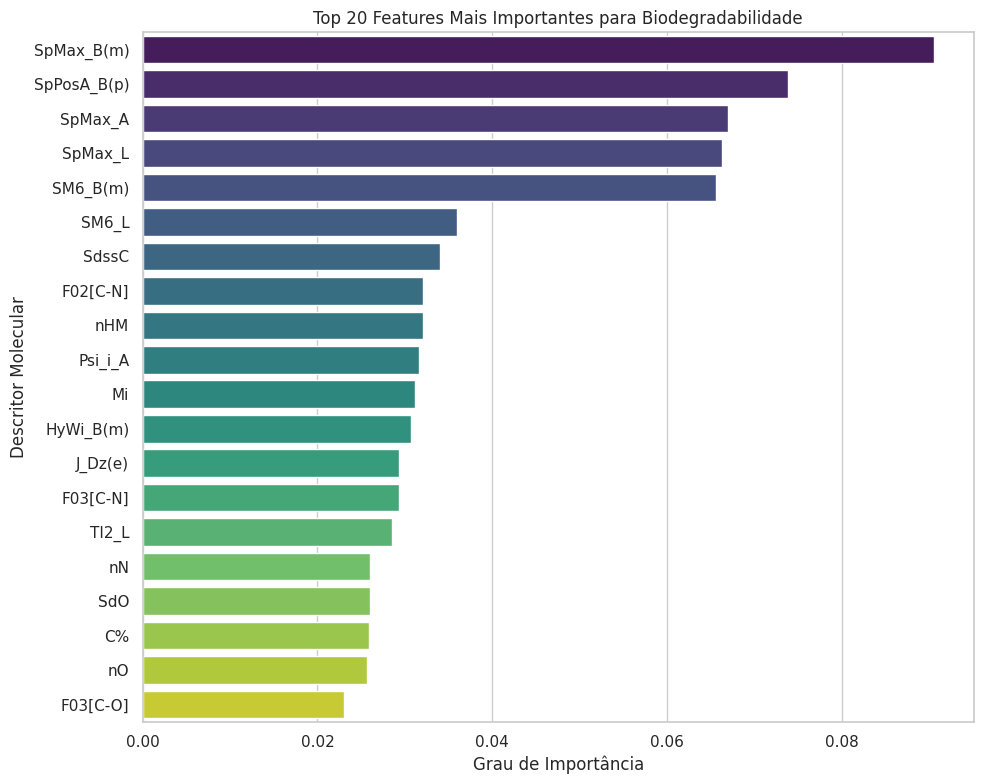

Top 20 features selecionadas: ['SpMax_B(m)', 'SpPosA_B(p)', 'SpMax_A', 'SpMax_L', 'SM6_B(m)', 'SM6_L', 'SdssC', 'F02[C-N]', 'nHM', 'Psi_i_A', 'Mi', 'HyWi_B(m)', 'J_Dz(e)', 'F03[C-N]', 'TI2_L', 'nN', 'SdO', 'C%', 'nO', 'F03[C-O]']


In [7]:
# Gráfico de importância das features (dados calculados na divisão inicial)
importancias_sorted = importancias.sort_values(by='Imp', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x='Imp', y='Feature', data=importancias_sorted.head(20), palette='viridis')
plt.title('Top 20 Features Mais Importantes para Biodegradabilidade')
plt.xlabel('Grau de Importância')
plt.ylabel('Descritor Molecular')
plt.tight_layout()
plt.show()
print(f'Top 20 features selecionadas: {top_20}')

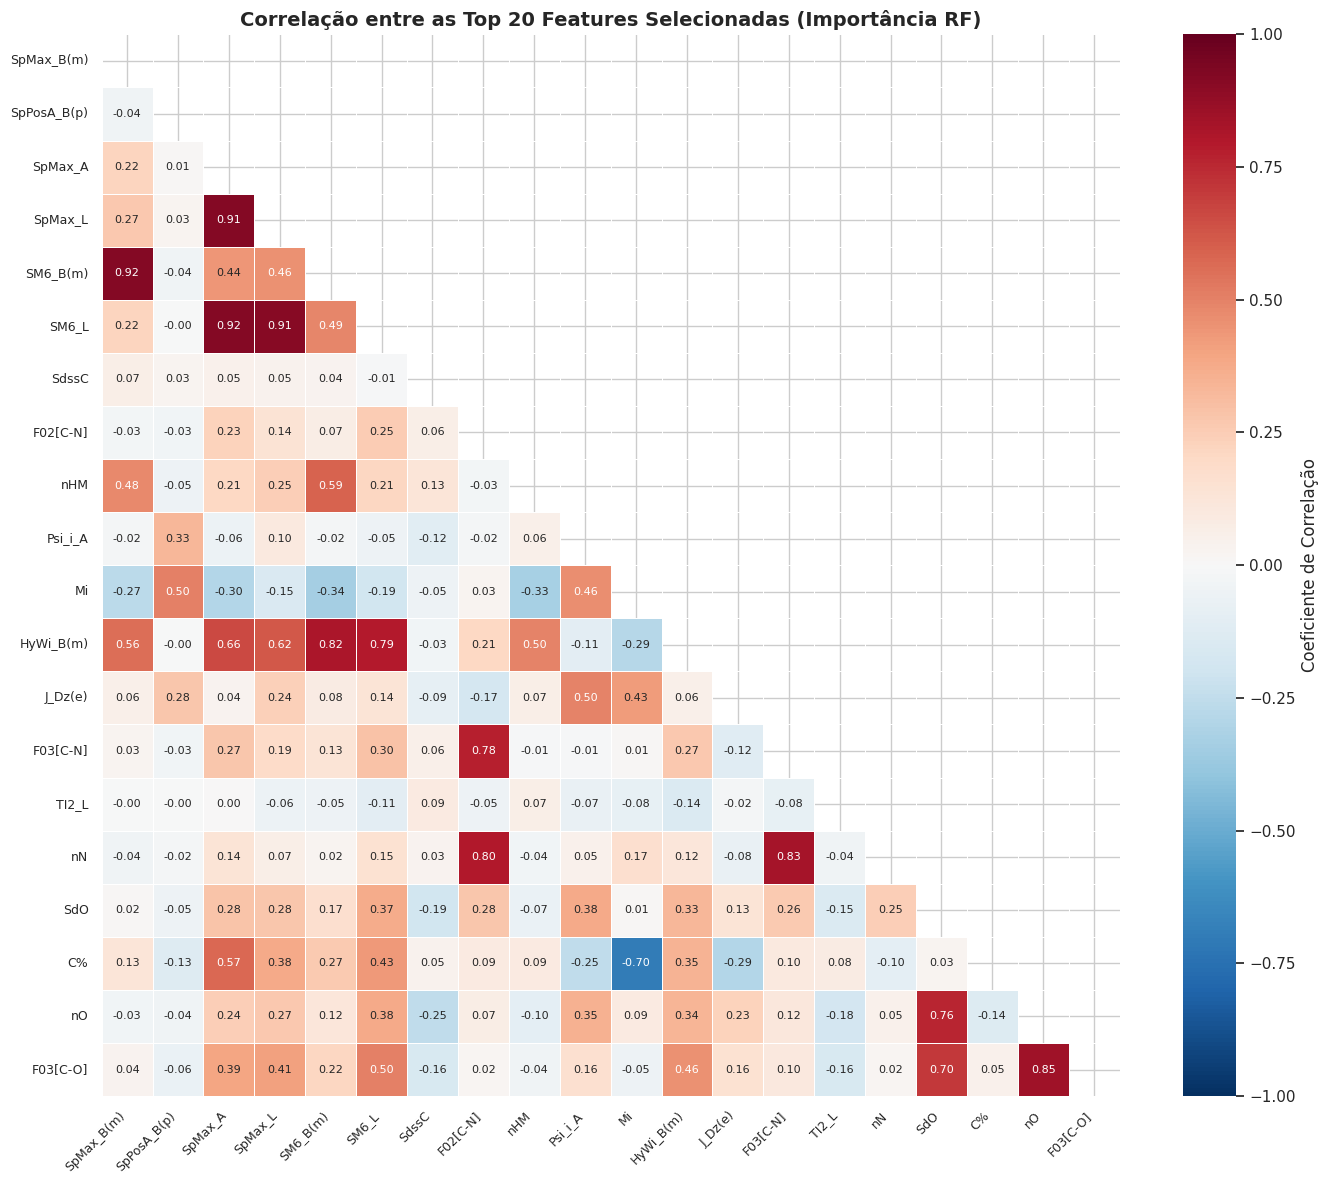

Pares com |r| > 0.7 (redundância potencial entre features selecionadas):
  SM6_L                × SpMax_A               r=0.921
  SM6_B(m)             × SpMax_B(m)            r=0.915
  SpMax_A              × SpMax_L               r=0.914
  SM6_L                × SpMax_L               r=0.910
  F03[C-O]             × nO                    r=0.849
  F03[C-N]             × nN                    r=0.833
  HyWi_B(m)            × SM6_B(m)              r=0.818
  F02[C-N]             × nN                    r=0.799
  HyWi_B(m)            × SM6_L                 r=0.793
  F02[C-N]             × F03[C-N]              r=0.780
  SdO                  × nO                    r=0.759
  F03[C-O]             × SdO                   r=0.704


In [8]:
# ── Mapa de Correlação das Features Selecionadas (Top 20 RF) ─────────────────
# Diferente do mapa da EDA (que usou Top 20 por variância), este mostra
# especificamente as features que os modelos supervisionados utilizam.
corr_rf = X_train_20.corr()

plt.figure(figsize=(14, 12))
mask_rf = np.triu(np.ones_like(corr_rf, dtype=bool))
sns.heatmap(corr_rf, mask=mask_rf, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size': 8},
            cbar_kws={'label': 'Coeficiente de Correlação'})
plt.title('Correlação entre as Top 20 Features Selecionadas (Importância RF)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Pares altamente correlacionados (possível redundância)
corr_abs_rf = corr_rf.abs()
corr_arr_rf = corr_abs_rf.to_numpy().copy()
np.fill_diagonal(corr_arr_rf, 0)
corr_abs_rf = pd.DataFrame(corr_arr_rf, index=corr_abs_rf.index, columns=corr_abs_rf.columns)

high_rf = [(r, c, corr_rf.loc[r, c])
           for r in corr_abs_rf.index for c in corr_abs_rf.columns
           if corr_abs_rf.loc[r, c] > 0.7 and r < c]

if high_rf:
    print('Pares com |r| > 0.7 (redundância potencial entre features selecionadas):')
    for r, c, val in sorted(high_rf, key=lambda x: -abs(x[2])):
        print(f'  {r:20s} × {c:20s}  r={val:.3f}')
else:
    print('Nenhum par com |r| > 0.7 entre as features selecionadas.')


## 3. Remoção de Outliers Multivariada (Isolation Forest)
Removeremos anomalias globais (5% mais extremos) **apenas no conjunto de treinamento**, preservando o conjunto de Teste como uma representação fiel das incertezas do mundo real.

In [9]:
print("--- Removendo Outliers (Isolation Forest) do Treino ---")
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(X_train_20)

mask_inliers = (outlier_labels == 1)
X_train_clean = X_train_20[mask_inliers]
y_train_clean = y_train[mask_inliers]

print(f"Amostras removidas (anomalias): {len(y_train) - len(y_train_clean)}")
print(f"Novo tamanho do conjunto de treino: {X_train_clean.shape[0]} amostras")

--- Removendo Outliers (Isolation Forest) do Treino ---
Amostras removidas (anomalias): 42
Novo tamanho do conjunto de treino: 799 amostras


## 4. Normalização (Z-Score) e Balanceamento (SMOTE)
A normalização Z-Score foi aplicada no passo anterior diretamente sobre os dados de treino limpos. O balanceamento com SMOTE é tratado **dentro do pipeline do GridSearchCV**, sendo aplicado dinamicamente em cada dobra do 5-Fold CV — garantindo que amostras sintéticas nunca contaminem o fold de validação usado para estimar a performance durante a busca de hiperparâmetros.

In [10]:
# Normalização Z-Score — fit apenas no treino limpo, transform passivo no teste
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_clean), columns=top_20)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_20), columns=top_20)

print(f'Treino normalizado (sem SMOTE global): {X_train_scaled.shape}')
print(f'Teste normalizado:  {X_test_scaled.shape}')
print(f'Classes no treino — NRB: {(y_train_clean == 0).sum()}, RB: {(y_train_clean == 1).sum()}')
print('SMOTE será aplicado per fold dentro do pipeline do GridSearchCV.')


Treino normalizado (sem SMOTE global): (799, 20)
Teste normalizado:  (211, 20)
Classes no treino — NRB: 523, RB: 276
SMOTE será aplicado per fold dentro do pipeline do GridSearchCV.


## 5. Configuração da Avaliação e Modelagem Supervisionada
Usaremos um `Pipeline` do `imblearn` que encapsula o SMOTE e o classificador, garantindo que o balanceamento seja aplicado **apenas nos dados de treino de cada dobra** durante o `GridSearchCV` com 5-Fold Cross Validation. O conjunto de teste (20%) permanece intocado até a avaliação final.

In [11]:
resultados_modelos = {}

def avaliar_modelo_cv(nome, modelo, params):
    print(f"\n{'='*60}\n--- Treinando e Otimizando: {nome} (5-Fold CV) ---\n{'='*60}")
    
    # 1. Criação do Pipeline (SMOTE + Modelo)
    # O SMOTE será aplicado dinamicamente em cada dobra do Cross-Validation
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', modelo)
    ])
    
    # 2. Ajuste dos nomes dos parâmetros
    # Como o modelo está dentro de um pipeline sob o nome 'classifier', 
    # precisamos de adicionar o prefixo 'classifier__' aos parâmetros.
    grid_params = {f'classifier__{key}': value for key, value in params.items()}
    
    # 3. GridSearchCV com 5-Fold Cross Validation
    grid = GridSearchCV(pipeline, grid_params, cv=5, scoring='f1_macro', n_jobs=-1)
    
    # O treino recebe os dados limpos (o pipeline encarrega-se do SMOTE internamente)
    grid.fit(X_train_scaled, y_train_clean)
    
    best_model = grid.best_estimator_
    
    # Limpando o prefixo para imprimir os hiperparâmetros de forma legível
    best_params_clean = {k.replace('classifier__', ''): v for k, v in grid.best_params_.items()}
    print(f"Melhores Hiperparâmetros: {best_params_clean}")
    
    # 4. Avaliação Final no Conjunto de TESTE (20% originais)
    y_pred = best_model.predict(X_test_scaled)
    
    print("\nRelatório de Classificação no Conjunto de TESTE:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Matriz de Confusão - {nome}')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.show()
    return best_model

## 6. Treinamento dos Modelos
Execução da Árvore de Decisão, K-Nearest Neighbors (KNN) e Rede Neural Artificial (MLP) com busca de hiperparâmetros via `GridSearchCV` com **5-Fold Cross Validation**. O SMOTE é aplicado dentro de um `ImbPipeline` em cada dobra, garantindo que o balanceamento não vaze para o fold de validação.


--- Treinando e Otimizando: Decision Tree (5-Fold CV) ---


Melhores Hiperparâmetros: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}

Relatório de Classificação no Conjunto de TESTE:
              precision    recall  f1-score   support

         NRB       0.85      0.86      0.85       140
          RB       0.71      0.70      0.71        71

    accuracy                           0.81       211
   macro avg       0.78      0.78      0.78       211
weighted avg       0.81      0.81      0.81       211



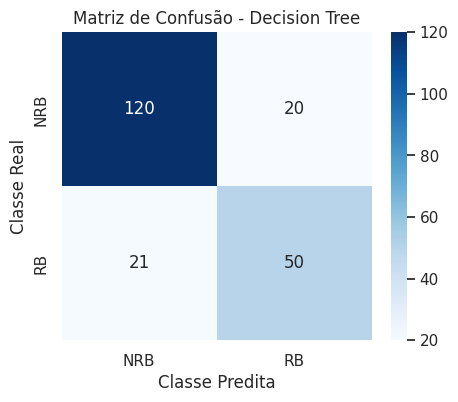


--- Treinando e Otimizando: KNN (5-Fold CV) ---


Melhores Hiperparâmetros: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}

Relatório de Classificação no Conjunto de TESTE:
              precision    recall  f1-score   support

         NRB       0.93      0.80      0.86       140
          RB       0.69      0.89      0.78        71

    accuracy                           0.83       211
   macro avg       0.81      0.84      0.82       211
weighted avg       0.85      0.83      0.83       211



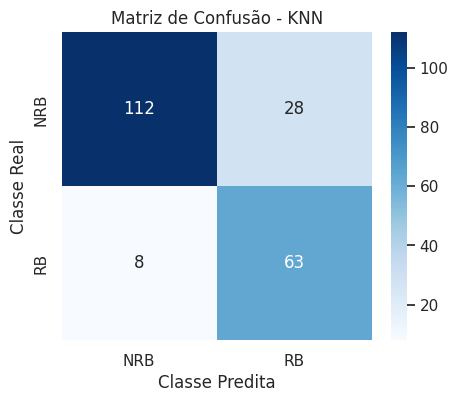


--- Treinando e Otimizando: Rede Neural (MLP) (5-Fold CV) ---


Melhores Hiperparâmetros: {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}

Relatório de Classificação no Conjunto de TESTE:
              precision    recall  f1-score   support

         NRB       0.90      0.87      0.89       140
          RB       0.76      0.82      0.79        71

    accuracy                           0.85       211
   macro avg       0.83      0.84      0.84       211
weighted avg       0.86      0.85      0.85       211



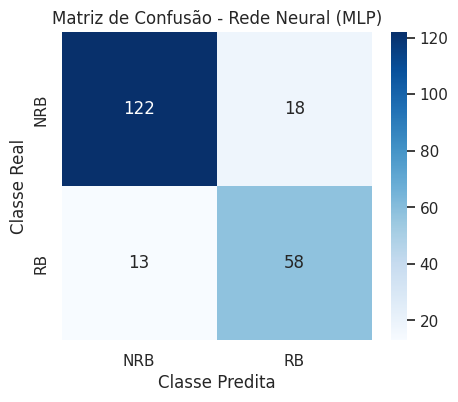

In [12]:
# 1. Decision Tree
param_dt = {'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, 15, 20, None],
            'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 5, 10], 'class_weight': [None, 'balanced']}
dt_model = avaliar_modelo_cv("Decision Tree", DecisionTreeClassifier(random_state=42), param_dt)

# 2. KNN
param_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15, 19], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}
knn_model = avaliar_modelo_cv("KNN", KNeighborsClassifier(), param_knn)

# 3. Rede Neural (MLP)
param_mlp = {'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
             'activation': ['relu', 'tanh', 'logistic'], 'alpha': [0.0001, 0.001, 0.01, 0.1], 'learning_rate_init': [0.001, 0.01]}
mlp_model = avaliar_modelo_cv("Rede Neural (MLP)", MLPClassifier(max_iter=1000, random_state=42, early_stopping=False), param_mlp)

## 7. Modelagem Não Supervisionada (K-Means)
Vamos esquecer temporariamente os rótulos originais (`y`) e verificar como os dados moleculares se agrupam naturalmente. Usaremos os dados de treino padronizados (`X_kmeans`), preparados exclusivamente para esta trilha.

Conforme especificado, iteraremos com $K$ variando de 2 a 10 e utilizaremos duas abordagens em conjunto para decidir o melhor $K$:
1. **Método do Cotovelo (Inércia / WCSS):** Busca o ponto onde a adição de novos clusters deixa de reduzir significativamente a variância interna.
2. **Silhouette Score:** Mede o quão similar um objeto é ao seu próprio cluster em comparação com outros clusters (varia de -1 a 1, sendo quanto mais próximo de 1, melhor).

--- Preparando Dataset Exclusivo para K-Means ---


Dimensões do dataset após limpeza global: (799, 20)
Nota: Dataset pronto, contendo as Top 20 features, normalizado e 100% livre de outliers.



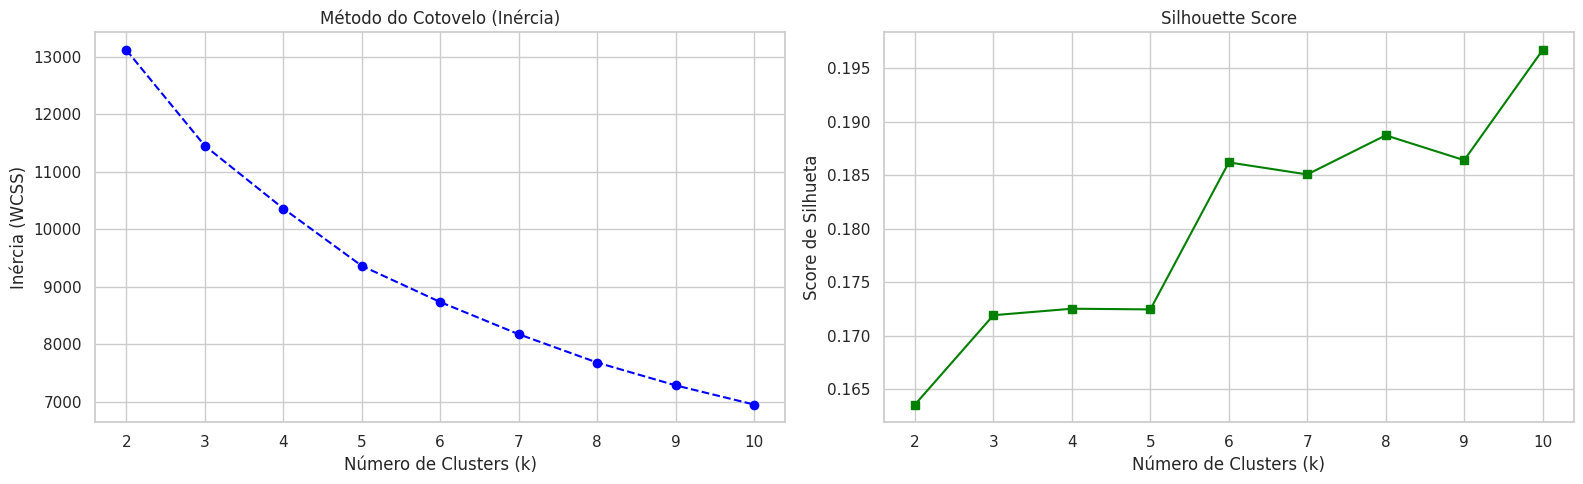

In [13]:
# =====================================================================
# PREPARAÇÃO EXCLUSIVA PARA O K-MEANS
# =====================================================================
print("--- Preparando Dataset Exclusivo para K-Means ---")

# 1. Remoção de Outliers (Apenas para a Trilha Não Supervisionada)
iso_kmeans = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
outliers_kmeans = iso_kmeans.fit_predict(X_train_20)

# Filtrando os inliers (dados normais)
mask_kmeans_inliers = (outliers_kmeans == 1)
X_kmeans_clean = X_train_20[mask_kmeans_inliers]
y_kmeans_clean = y_train[mask_kmeans_inliers]

# 2. Normalização (Z-Score) do Dataset Global Limpo
scaler_kmeans = StandardScaler()
X_kmeans = pd.DataFrame(scaler_kmeans.fit_transform(X_kmeans_clean), columns=top_20)

print(f"Dimensões do dataset após limpeza global: {X_kmeans.shape}")
print("Nota: Dataset pronto, contendo as Top 20 features, normalizado e 100% livre de outliers.\n")

# =====================================================================
# EXECUÇÃO DO K-MEANS (Cotovelo e Silhouette)
# =====================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    # Usamos o X_kmeans limpo!
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans)

    inercia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans, kmeans.labels_))

# Plotando os gráficos (Método do Cotovelo e Silhouette)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(K_range, inercia, marker='o', color='blue', linestyle='--')
ax[0].set_title('Método do Cotovelo (Inércia)')
ax[0].set_xlabel('Número de Clusters (k)')
ax[0].set_ylabel('Inércia (WCSS)')
ax[0].set_xticks(K_range)

ax[1].plot(K_range, silhouette_scores, marker='s', color='green', linestyle='-')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Número de Clusters (k)')
ax[1].set_ylabel('Score de Silhueta')
ax[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

---
## Escolha do k para o K-Means (baseada nos gráficos gerados)

A análise conjunta dos dois critérios indica:

**Método do Cotovelo (Inércia):**  
A curva de inércia decresce de forma suave e contínua de k=2 até k=10, sem apresentar um cotovelo nítido. As maiores quedas ocorrem entre k=2→3 e k=3→4; a partir de k=5 a redução marginal diminui consideravelmente, sugerindo que clusters adicionais trazem ganho marginal pequeno.

**Silhouette Score:**  
Os valores são baixos em toda a faixa (máx. ≈ 0.18), o que reflete sobreposição natural entre as classes moleculares. Nenhum k domina claramente os demais — a amplitude total dos scores é pequena (≈ 0.02), indicando que a estrutura de agrupamento no espaço molecular é difusa.

**Decisão:**  
Optamos por **k=2** como escolha principal, pois:
1. O problema é originalmente binário (RB vs NRB) — testar se o K-Means recupera essa estrutura é a pergunta central da análise não supervisionada;
2. k=2 corresponde à maior redução de inércia na transição mais relevante do cotovelo;
3. Os silhouette scores ao longo de toda a faixa são próximos entre si, indicando que nenhum k é claramente dominante pela separabilidade.

Como análise complementar, testamos também **k=5** (melhor pico local do silhouette após k=2), para verificar se estruturas moleculares mais granulares emergem naturalmente.

In [14]:
# ── Execução com k=2 (análise principal) e k=5 (análise complementar) ────────
for melhor_k, rotulo in [(2, 'Principal (k=2, semântico)'), (5, 'Complementar (k=5, silhouette local)')]:
    print(f"\n{'='*65}")
    print(f"  K-Means — {rotulo}")
    print(f"{'='*65}")

    km = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
    clusters_k = km.fit_predict(X_kmeans)
    sil = silhouette_score(X_kmeans, clusters_k)
    print(f"  Inércia: {km.inertia_:.1f}  |  Silhouette: {sil:.4f}")

    df_comp = pd.DataFrame({
        'Classe_Real': label_encoder.inverse_transform(y_kmeans_clean),
        'Cluster': clusters_k
    })
    print("\n  Tabela de Contingência:")
    display(pd.crosstab(df_comp['Classe_Real'], df_comp['Cluster'],
                        rownames=['Classe Original'], colnames=['Cluster']))

# Salvamos o modelo k=2 para os plots seguintes
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_pred = kmeans_final.fit_predict(X_kmeans)

print("\nNota: Como o aprendizado é não-supervisionado, os rótulos do cluster (0 e 1) "
      "podem estar invertidos em relação aos rótulos originais. O que importa é a pureza "
      "de cada cluster (se ele isolou bem a maioria das instâncias RB de um lado e NRB do outro).")


  K-Means — Principal (k=2, semântico)
  Inércia: 13114.2  |  Silhouette: 0.1635

  Tabela de Contingência:


Cluster,0,1
Classe Original,,
NRB,169,354
RB,193,83



  K-Means — Complementar (k=5, silhouette local)
  Inércia: 9363.5  |  Silhouette: 0.1724

  Tabela de Contingência:


Cluster,0,1,2,3,4
Classe Original,,,,,
NRB,63,76,120,91,173
RB,2,111,99,3,61



Nota: Como o aprendizado é não-supervisionado, os rótulos do cluster (0 e 1) podem estar invertidos em relação aos rótulos originais. O que importa é a pureza de cada cluster (se ele isolou bem a maioria das instâncias RB de um lado e NRB do outro).


## 8. Visualização dos Clusters (Redução de Dimensionalidade com PCA)
O espaço das Top 20 features selecionadas ainda possui dimensões demais para visualização direta. Usaremos a Análise de Componentes Principais (PCA) para comprimir as 20 features em 2 componentes e enxergar a distribuição espacial dos clusters formados pelo K-Means.

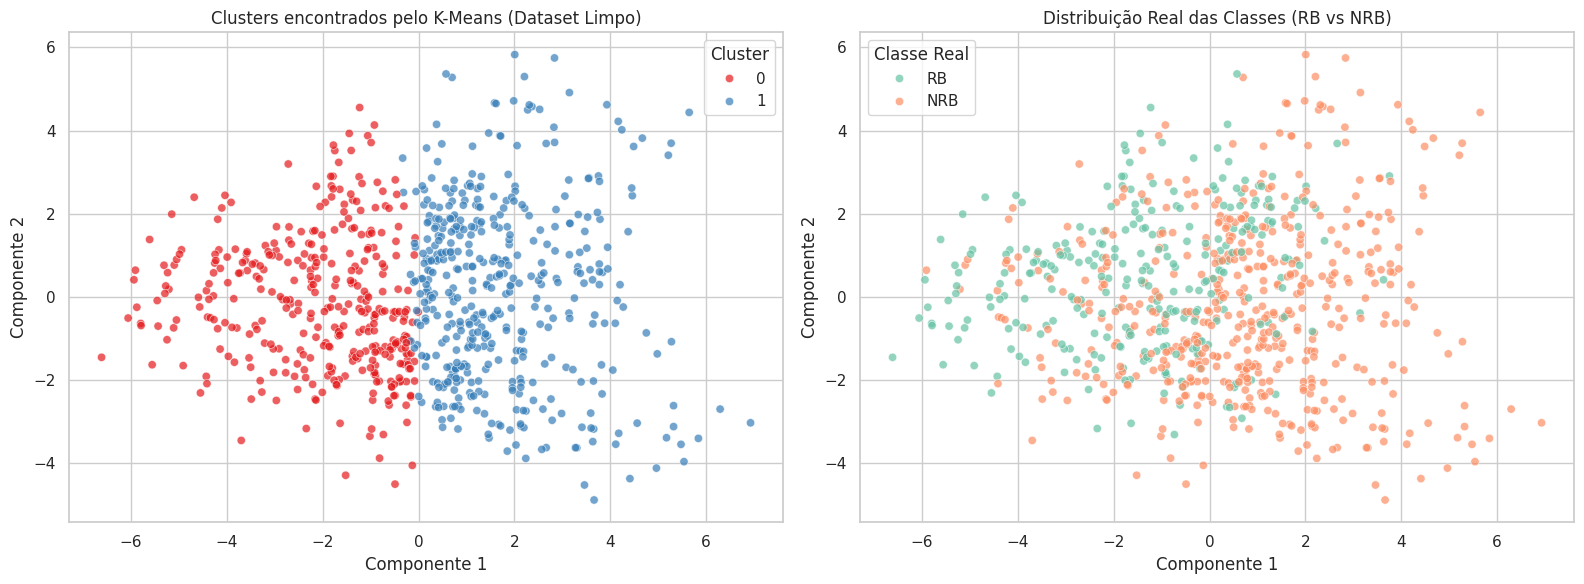

Variância explicada pelos 2 componentes: 46.57%


In [15]:
from sklearn.decomposition import PCA

# Aplicando PCA para reduzir para 2 dimensões (usando X_kmeans)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_kmeans)
df_pca = pd.DataFrame(data = X_pca, columns = ['Componente 1', 'Componente 2'])
df_pca['Cluster'] = clusters_pred
df_pca['Classe Real'] = label_encoder.inverse_transform(y_kmeans_clean)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='Componente 1', y='Componente 2', hue='Cluster', palette='Set1', data=df_pca, ax=ax[0], alpha=0.7)
ax[0].set_title('Clusters encontrados pelo K-Means (Dataset Limpo)')

sns.scatterplot(x='Componente 1', y='Componente 2', hue='Classe Real', palette='Set2', data=df_pca, ax=ax[1], alpha=0.7)
ax[1].set_title('Distribuição Real das Classes (RB vs NRB)')
plt.tight_layout()
plt.show()

print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.2f}%")

---
## 9. Análise dos Centroides dos Clusters
Para interpretar *o que cada cluster representa quimicamente*, comparamos os valores médios das 20 features em cada cluster com a média global. Desvios positivos indicam features acima da média naquele grupo.

Cluster 0 → classe majoritária: RB (53.3%)
Cluster 1 → classe majoritária: NRB (81.0%)


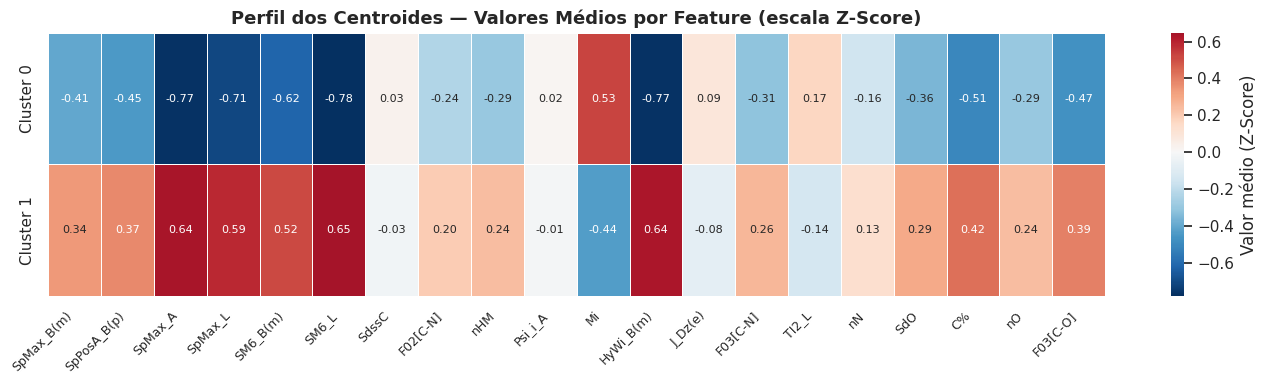

In [16]:
# ── Perfil dos Centroides ────────────────────────────────────────────────────
centroides = pd.DataFrame(kmeans_final.cluster_centers_, columns=top_20)
centroides.index = [f'Cluster {i}' for i in range(2)]

df_comp_final = pd.DataFrame({
    'Classe_Real': label_encoder.inverse_transform(y_kmeans_clean),
    'Cluster': clusters_pred
})
for c in range(2):
    majoritaria = df_comp_final[df_comp_final['Cluster'] == c]['Classe_Real'].value_counts().idxmax()
    pct = df_comp_final[df_comp_final['Cluster'] == c]['Classe_Real'].value_counts(normalize=True).max()
    print(f"Cluster {c} → classe majoritária: {majoritaria} ({pct*100:.1f}%)")

plt.figure(figsize=(14, 4))
sns.heatmap(centroides, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'label': 'Valor médio (Z-Score)'})
plt.title('Perfil dos Centroides — Valores Médios por Feature (escala Z-Score)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

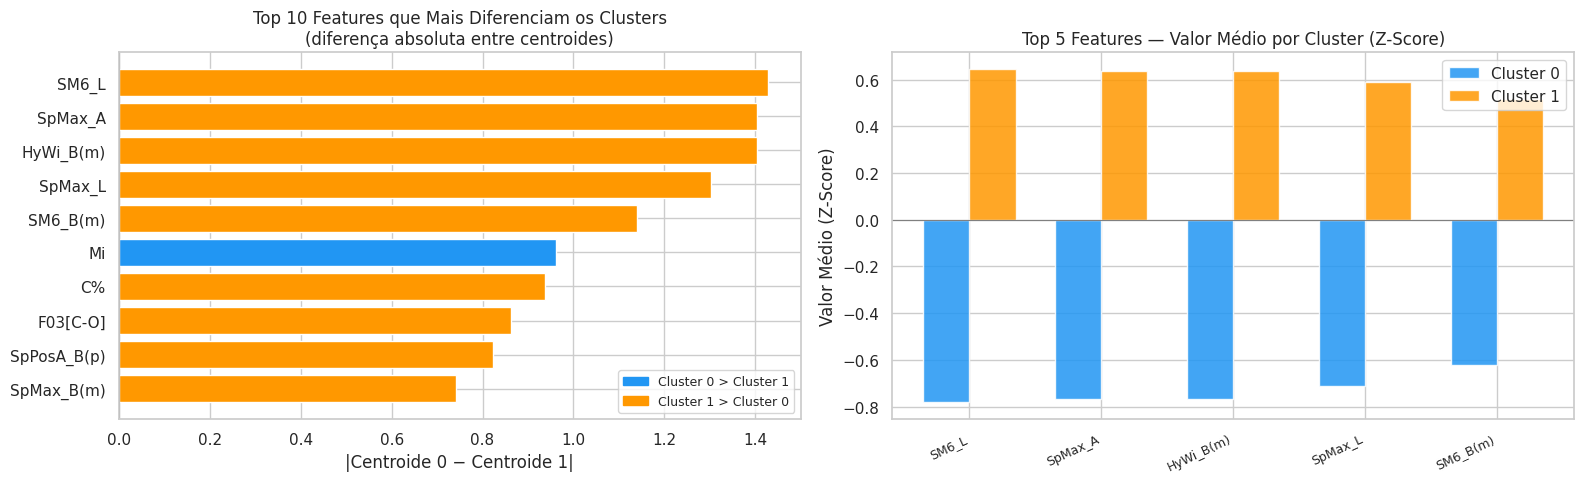


Interpretação sugerida:
Features com Z-Score positivo alto → descritores moleculares elevados naquele cluster.
Compare com a classe majoritária para inferir o perfil químico (ex.: moléculas mais complexas → NRB).


In [17]:
# ── Top features que mais diferenciam os clusters ───────────────────────────
from matplotlib.patches import Patch

diff_centroides = (centroides.loc['Cluster 0'] - centroides.loc['Cluster 1']).abs()
top10_diff = diff_centroides.nlargest(10)

cores = ['#2196F3' if centroides.loc['Cluster 0', f] > centroides.loc['Cluster 1', f]
         else '#FF9800' for f in top10_diff.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].barh(top10_diff.index[::-1], top10_diff.values[::-1],
                    color=cores[::-1], edgecolor='white')
axes[0].set_title('Top 10 Features que Mais Diferenciam os Clusters\n(diferença absoluta entre centroides)', fontsize=12)
axes[0].set_xlabel('|Centroide 0 − Centroide 1|')
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].legend(handles=[Patch(color='#2196F3', label='Cluster 0 > Cluster 1'),
                         Patch(color='#FF9800', label='Cluster 1 > Cluster 0')],
               fontsize=9, loc='lower right')

top5 = top10_diff.nlargest(5).index.tolist()
x = np.arange(len(top5))
w = 0.35
axes[1].bar(x - w/2, centroides.loc['Cluster 0', top5], w,
            label='Cluster 0', color='#2196F3', alpha=0.85)
axes[1].bar(x + w/2, centroides.loc['Cluster 1', top5], w,
            label='Cluster 1', color='#FF9800', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top5, rotation=25, ha='right', fontsize=9)
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('Top 5 Features — Valor Médio por Cluster (Z-Score)', fontsize=12)
axes[1].set_ylabel('Valor Médio (Z-Score)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nInterpretação sugerida:")
print("Features com Z-Score positivo alto → descritores moleculares elevados naquele cluster.")
print("Compare com a classe majoritária para inferir o perfil químico (ex.: moléculas mais complexas → NRB).")

---
## 10. Tabela Comparativa Final dos Modelos Supervisionados
Consolidação dos resultados de todos os modelos no conjunto de teste para facilitar a análise crítica comparativa.

In [18]:
# ── Tabela Comparativa ───────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score

modelos_dict = {
    'Decision Tree':    dt_model,
    'KNN':              knn_model,
    'MLP (Rede Neural)': mlp_model
}

linhas = []
for nome, modelo in modelos_dict.items():
    y_pred = modelo.predict(X_test_scaled)
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test_scaled)
    auc = roc_auc_score(y_test, y_prob)
    linhas.append({
        'Modelo':         nome,
        'Acurácia':       accuracy_score(y_test, y_pred),
        'F1-Macro':       f1_score(y_test, y_pred, average='macro'),
        'F1-RB':          f1_score(y_test, y_pred, average=None)[label_encoder.transform(['RB'])[0]],
        'F1-NRB':         f1_score(y_test, y_pred, average=None)[label_encoder.transform(['NRB'])[0]],
        'Precisão-Macro': precision_score(y_test, y_pred, average='macro'),
        'Recall-Macro':   recall_score(y_test, y_pred, average='macro'),
        'AUC-ROC':        auc
    })

df_resultados = pd.DataFrame(linhas).set_index('Modelo')
print('=== Comparativo de Modelos no Conjunto de Teste ===')
display(df_resultados.round(4))
melhor = df_resultados['F1-Macro'].idxmax()
print(f'Melhor modelo por F1-Macro: {melhor} ({df_resultados["F1-Macro"].max():.4f})')


=== Comparativo de Modelos no Conjunto de Teste ===


,Acurácia,F1-Macro,F1-RB,F1-NRB,Precisão-Macro,Recall-Macro,AUC-ROC
Modelo,,,,,,,
Decision Tree,0.8057,0.7817,0.7092,0.8541,0.7827,0.7807,0.8009
KNN,0.8294,0.8197,0.7778,0.8615,0.8128,0.8437,0.9071
MLP (Rede Neural),0.8531,0.8382,0.7891,0.8873,0.8334,0.8442,0.9006


Melhor modelo por F1-Macro: MLP (Rede Neural) (0.8382)


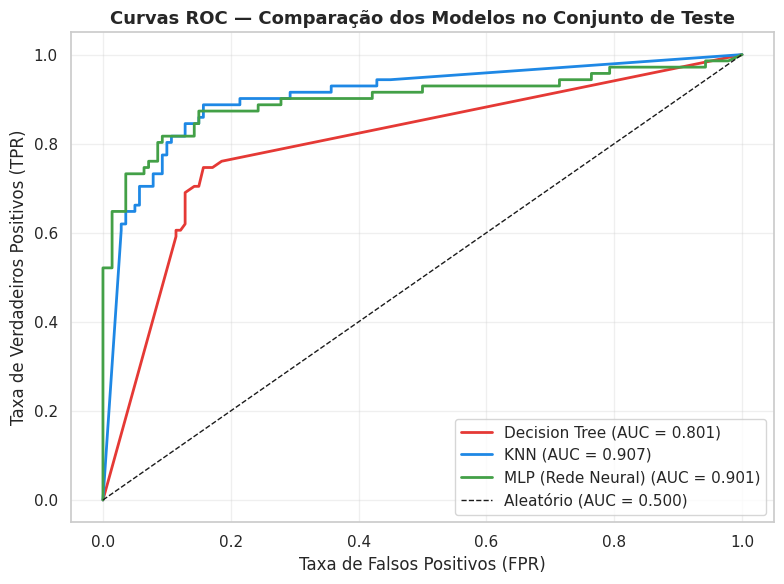

In [19]:
# ── Curvas ROC comparativas ──────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
cores_roc = {'Decision Tree': '#E53935', 'KNN': '#1E88E5', 'MLP (Rede Neural)': '#43A047'}

for nome, modelo in modelos_dict.items():
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})',
             color=cores_roc[nome], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.500)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC — Comparação dos Modelos no Conjunto de Teste', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

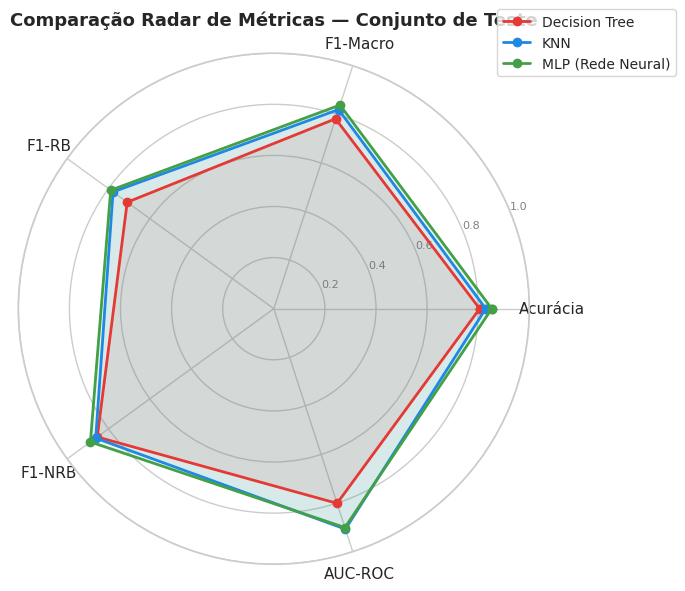

In [20]:
# ── Gráfico radar de métricas por modelo ────────────────────────────────────
metricas_radar = ['Acurácia', 'F1-Macro', 'F1-RB', 'F1-NRB', 'AUC-ROC']
N = len(metricas_radar)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
cores_radar = ['#E53935', '#1E88E5', '#43A047']

for (nome, row), cor in zip(df_resultados[metricas_radar].iterrows(), cores_radar):
    valores = row.tolist() + row.tolist()[:1]
    ax.plot(angulos, valores, 'o-', linewidth=2, label=nome, color=cor)
    ax.fill(angulos, valores, alpha=0.1, color=cor)

ax.set_thetagrids(np.degrees(angulos[:-1]), metricas_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='gray')
ax.set_title('Comparação Radar de Métricas — Conjunto de Teste',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()